## Задачи и метрики Audio ML

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchaudio
import os
import glob
import urllib.request
import tarfile
import matplotlib.pyplot as plt
import librosa
import numpy as np
from tqdm.notebook import tqdm
from collections import Counter
import sys
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Audio, clear_output
from torchsummary import summary

## Данные

In [ ]:
data_url = "https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz"
data_dir = "./data/speech_commands"

os.makedirs(data_dir, exist_ok=True)
tar_path = os.path.join(data_dir, "speech_commands.tar.gz")

if not os.path.exists(tar_path):
    print("Скачивание датасета...")
    urllib.request.urlretrieve(data_url, tar_path)

# Распаковка (может занять пару минут)
if not os.path.exists(os.path.join(data_dir, "yes")):
    print("Распаковка...")
    with tarfile.open(tar_path) as tar:
        tar.extractall(data_dir)

Скачивание датасета...
Распаковка...


/tmp/ipython-input-775/1265359733.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_dir)


Google Speech Commands — это набор односекундных аудиофайлов в формате .wav, предназначенный для обучения систем распознавания коротких голосовых команд (Keyword Spotting).

Количество слов: 35 различных английских слов.

Основные классы: yes, no, up, down, left, right, on, off, stop, go, а также цифры от zero до nine и другие.

Основные характеристики (v2):

Объем: 105 829 аудиозаписей.

Формат: Одноканальные WAV-файлы, 16 кГц, 16 бит, длительностью до 1 секунды.

In [ ]:
class YesNoDataset(Dataset):
    def __init__(self, root_dir, sample_rate=16000, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # Собираем пути к файлам
        yes_files = glob.glob(os.path.join(root_dir, "yes", "*.wav"))
        no_files = glob.glob(os.path.join(root_dir, "no", "*.wav"))

        self.file_paths = yes_files + no_files
        self.labels = [1] * len(yes_files) + [0] * len(no_files)  # yes=1, no=0

        # Проверим, что все файлы имеют одинаковую частоту дискретизации
        self.sample_rate = sample_rate  # стандарт для Speech Commands

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio_path = self.file_paths[idx]
        waveform, sr = torchaudio.load(audio_path)

        # Приведение к нужной частоте дискретизации
        if sr != self.sample_rate:
            waveform = torchaudio.functional.resample(waveform, sr, self.sample_rate)

        # Обрезка или дополнение до 1 секунды (16000 сэмплов)
        length = self.sample_rate
        if waveform.shape[1] > length:
            waveform = waveform[:, :length]
        elif waveform.shape[1] < length:
            padding = length - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, padding))

        # Преобразование в моно (если стерео)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        label = torch.tensor(self.labels[idx], dtype=torch.float)#.type(torch.FloatTensor)

        if self.transform:
            waveform = self.transform(waveform)

        return waveform, label

In [ ]:
yes_files = glob.glob(os.path.join("./data/speech_commands", "yes", "*.wav"))
no_files = glob.glob(os.path.join("./data/speech_commands", "no", "*.wav"))
print(f'no: {len(no_files)} \nyes: {len(yes_files)}')

no: 3941 
yes: 4044


In [ ]:
from torch.utils.data import random_split
torch.manual_seed(0)
sr = 16_000
length = sr

dataset = YesNoDataset("./data/speech_commands")

# # Разделение: 80% train, 20% test
train_size = int(0.8 * len(dataset))
valid_size = len(dataset) - train_size
train_dataset, valid_dataset = random_split(dataset, [train_size, valid_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
print(f'train: {len(train_dataset)} \nvalid: {len(valid_dataset)}')

train: 6388 
valid: 1597


In [ ]:
def print_balance(name, counts, total):
    yes_count = counts.get(1, 0)
    no_count = counts.get(0, 0)
    print(f"{name}:")
    print(f"  Всего: {total}")
    print(f"  Yes (1): {yes_count} ({yes_count/total:.2%})")
    print(f"  No  (0): {no_count} ({no_count/total:.2%})")
    print("-" * 30)

In [ ]:
train_labels = [dataset.labels[i] for i in train_dataset.indices]
test_labels = [dataset.labels[i] for i in valid_dataset.indices]

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

print_balance('train', train_counts, len(train_dataset))
print_balance('valid', test_counts, len(valid_dataset))

train:
  Всего: 6388
  Yes (1): 3266 (51.13%)
  No  (0): 3122 (48.87%)
------------------------------
valid:
  Всего: 1597
  Yes (1): 778 (48.72%)
  No  (0): 819 (51.28%)
------------------------------


In [ ]:
wave_no, target_no  = dataset[-1]
print(target_no.item())
Audio(wave_no, rate=sr)

0.0


In [ ]:
wave_yes, target_yes  = dataset[0]
print(target_yes.item())
Audio(wave_yes, rate=sr)

1.0


### Признаки

Все перечисленные способы представления аудиосигнала могут служить входными данными для нейронной сети

#### wave

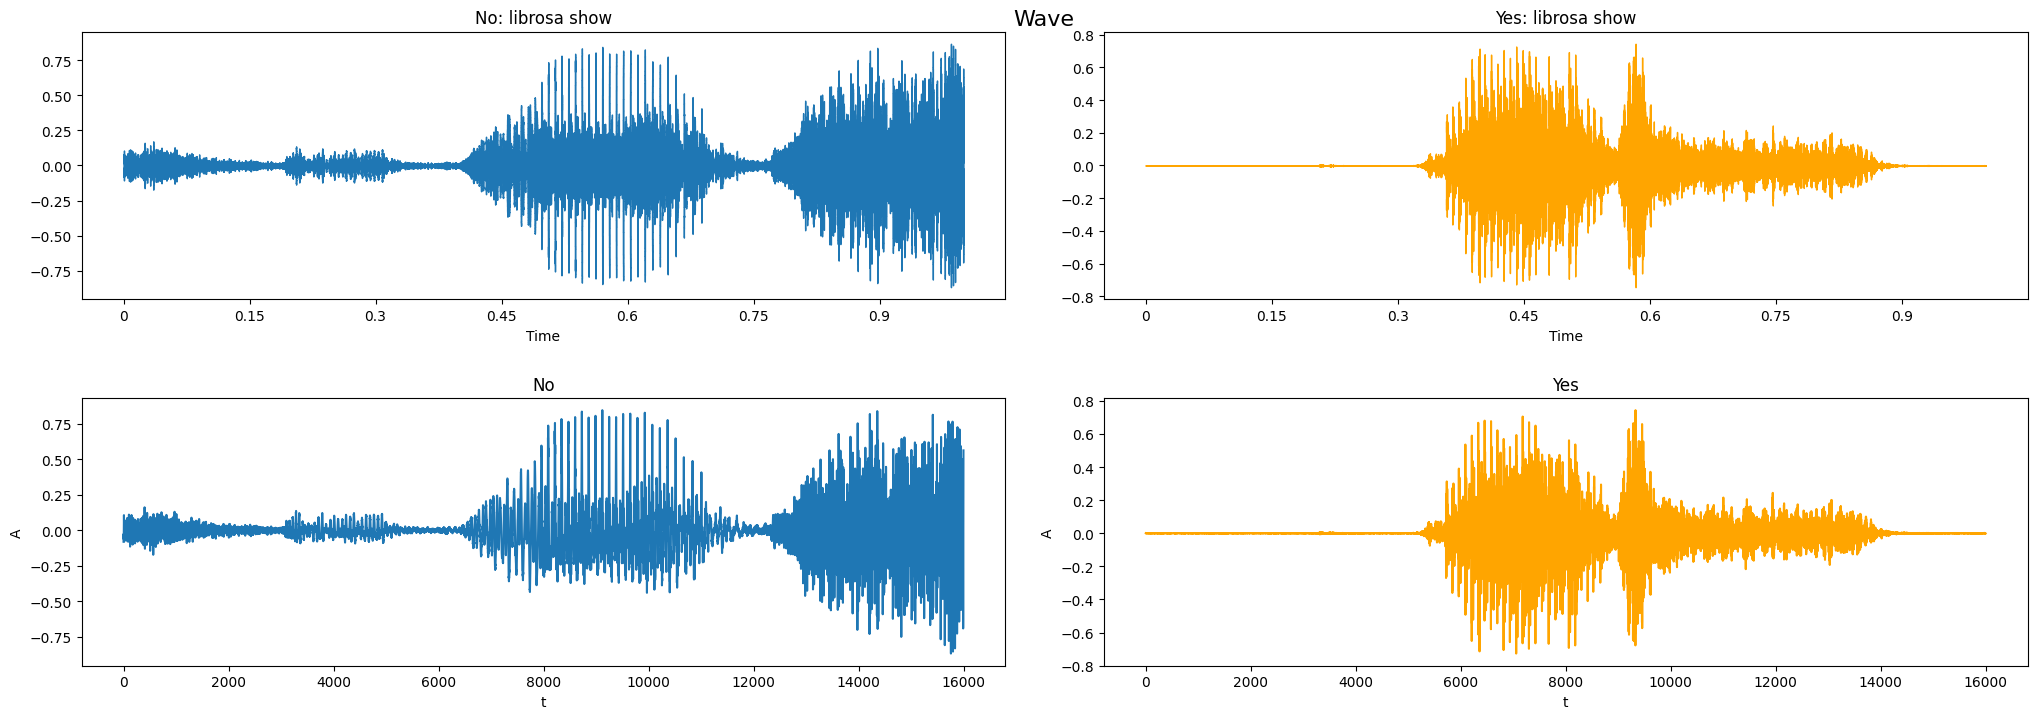

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(20, 7))
fig.suptitle('Wave', fontsize=16)

plt.tight_layout(pad=0.4, w_pad=4, h_pad=5.0)

ax[0, 0].set_title('No: librosa show')
librosa.display.waveshow(wave_no[0].numpy(), sr=sr, ax=ax[0, 0])

ax[0, 1].set_title('Yes: librosa show')
librosa.display.waveshow(wave_yes[0].numpy(), sr=sr, ax=ax[0, 1], color='orange')

ax[1, 0].set_title('No')
ax[1, 0].plot(wave_no[0])
ax[1, 0].set_xlabel('t')
ax[1, 0].set_ylabel('A');

ax[1, 1].set_title('Yes')
ax[1, 1].plot(wave_yes[0], color='orange')
ax[1, 1].set_xlabel('t')
ax[1, 1].set_ylabel('A');

#### STFT

(321, 51)


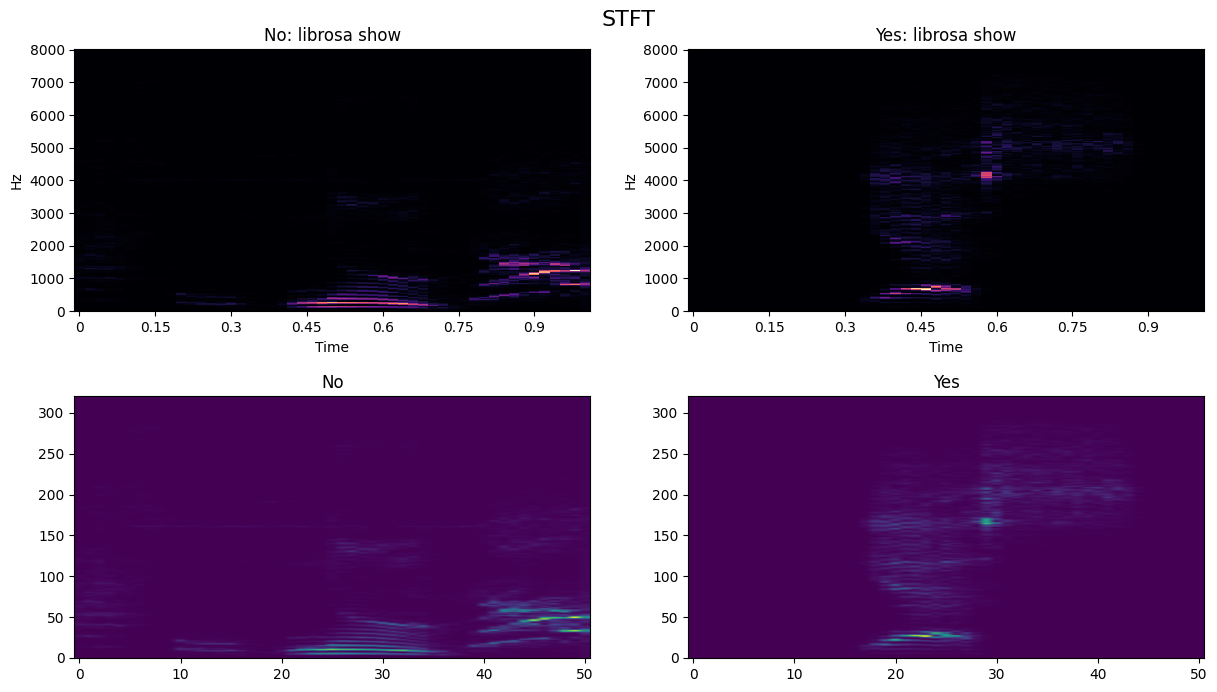

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(12, 7))
fig.suptitle('STFT', fontsize=16)

plt.tight_layout(pad=1, w_pad=4, h_pad=4.0)

n_fft= int(sr * (0.04)) # 40 ms
hop_length=int(n_fft//2)
win_length=n_fft

D_no = librosa.stft(wave_no[0].numpy(), n_fft=n_fft, hop_length=hop_length, win_length=win_length)  # линейная амплитуда частот

D_yes = librosa.stft(wave_yes[0].numpy(), n_fft=n_fft, hop_length=hop_length, win_length=win_length)

ax[0, 0].set_title('No: librosa show')
librosa.display.specshow(np.abs(D_no),
                         sr=16_000,
                         x_axis='time',
                         y_axis='hz',
                         cmap='magma',
                         ax=ax[0, 0],
                         n_fft=n_fft,
                         hop_length=hop_length,
                         win_length=win_length,
                         )

ax[0, 1].set_title('Yes: librosa show')
librosa.display.specshow(np.abs(D_yes),
                         sr=16_000,
                         x_axis='time',
                         y_axis='hz',
                         cmap='magma',
                         ax=ax[0, 1],
                         n_fft=n_fft,
                         hop_length=hop_length,
                         win_length=win_length,
                         )

ax[1, 0].set_title('No')
ax[1,0].imshow(np.abs(D_no), aspect='auto', origin='lower')

ax[1, 1].set_title('Yes')
ax[1,1].imshow(np.abs(D_yes), aspect='auto', origin='lower')

print(D_no.shape)

#### STFT dB

(321, 51)


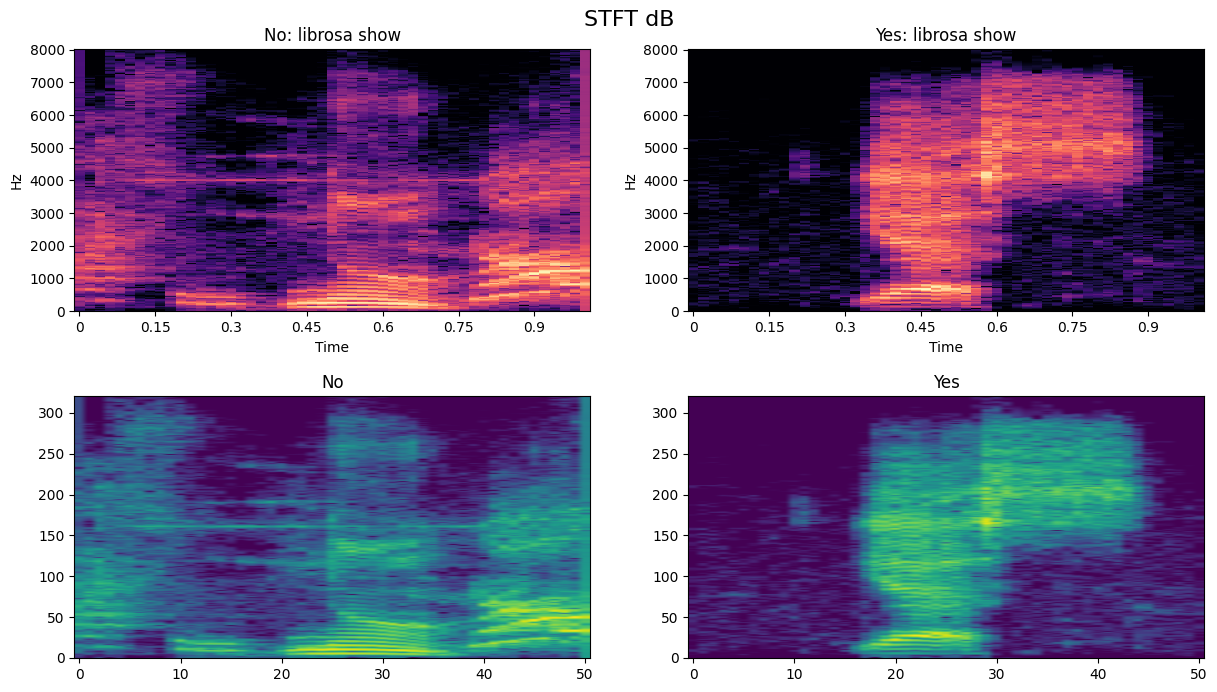

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(12, 7))
fig.suptitle('STFT dB', fontsize=16)

plt.tight_layout(pad=1, w_pad=4, h_pad=4.0)

n_fft= int(sr * (0.04)) # 40 ms
hop_length=int(n_fft//2)
win_length=n_fft

S_db_no = librosa.amplitude_to_db(np.abs(D_no), ref=np.max)

S_db_yes = librosa.amplitude_to_db(np.abs(D_yes), ref=np.max)

ax[0, 0].set_title('No: librosa show')
librosa.display.specshow(S_db_no,
                         sr=16_000,
                         x_axis='time',
                         y_axis='hz',
                         cmap='magma',
                         ax=ax[0, 0],
                         n_fft=n_fft,
                         hop_length=hop_length,
                         win_length=win_length,
                         )

ax[0, 1].set_title('Yes: librosa show')
librosa.display.specshow(S_db_yes,
                         sr=16_000,
                         x_axis='time',
                         y_axis='hz',
                         cmap='magma',
                         ax=ax[0, 1],
                         n_fft=n_fft,
                         hop_length=hop_length,
                         win_length=win_length,
                         )

ax[1, 0].set_title('No')
ax[1,0].imshow(S_db_no, aspect='auto', origin='lower')

ax[1, 1].set_title('Yes')
ax[1,1].imshow(S_db_yes, aspect='auto', origin='lower')

print(S_db_no.shape)

#### Mel

(32, 51)


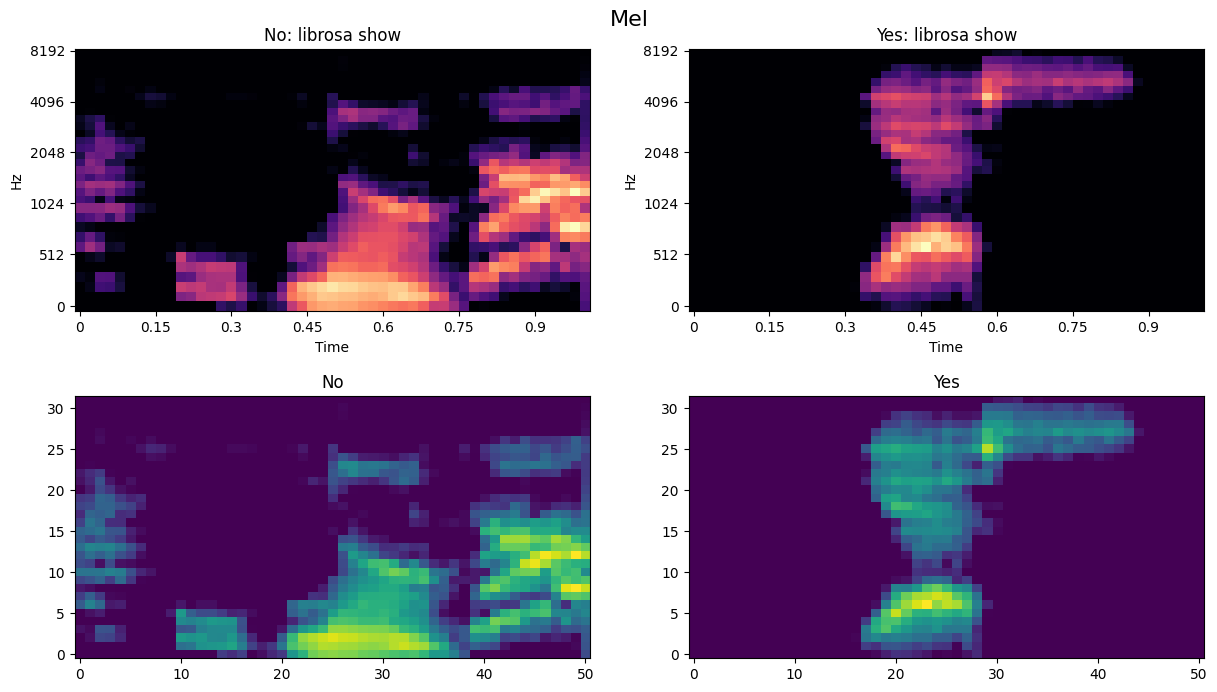

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(12, 7))
fig.suptitle('Mel', fontsize=16)

plt.tight_layout(pad=1, w_pad=4, h_pad=4.0)

S_no = librosa.feature.melspectrogram(
    y=wave_no[0].numpy(),
    n_fft=n_fft,
    hop_length=hop_length,
    win_length=win_length,
    sr=16_000,
    n_mels=32,
    fmax=8000
    )
S_yes = librosa.feature.melspectrogram(
    y=wave_yes[0].numpy(),
    n_fft=n_fft,
    hop_length=hop_length,
    win_length=win_length,
    sr=16_000,
    n_mels=32,
    fmax=8000
    )

S_db_no = librosa.amplitude_to_db(S_no, ref=np.max)

S_db_yes = librosa.amplitude_to_db(S_yes, ref=np.max)

ax[0, 0].set_title('No: librosa show')
librosa.display.specshow(S_db_no,
                         sr=16_000,
                         x_axis='time',
                         y_axis='mel',
                         cmap='magma',
                         ax=ax[0, 0],
                         n_fft=n_fft,
                         hop_length=hop_length,
                         win_length=win_length,
                         )

ax[0, 1].set_title('Yes: librosa show')
librosa.display.specshow(S_db_yes,
                         sr=16_000,
                         x_axis='time',
                         y_axis='mel',
                         cmap='magma',
                         ax=ax[0, 1],
                         n_fft=n_fft,
                         hop_length=hop_length,
                         win_length=win_length,
                         )

ax[1, 0].set_title('No')
ax[1,0].imshow(S_db_no, aspect='auto', origin='lower')

ax[1, 1].set_title('Yes')
ax[1,1].imshow(S_db_yes, aspect='auto', origin='lower')

print(S_db_no.shape)

#### MFCC

(16, 32)


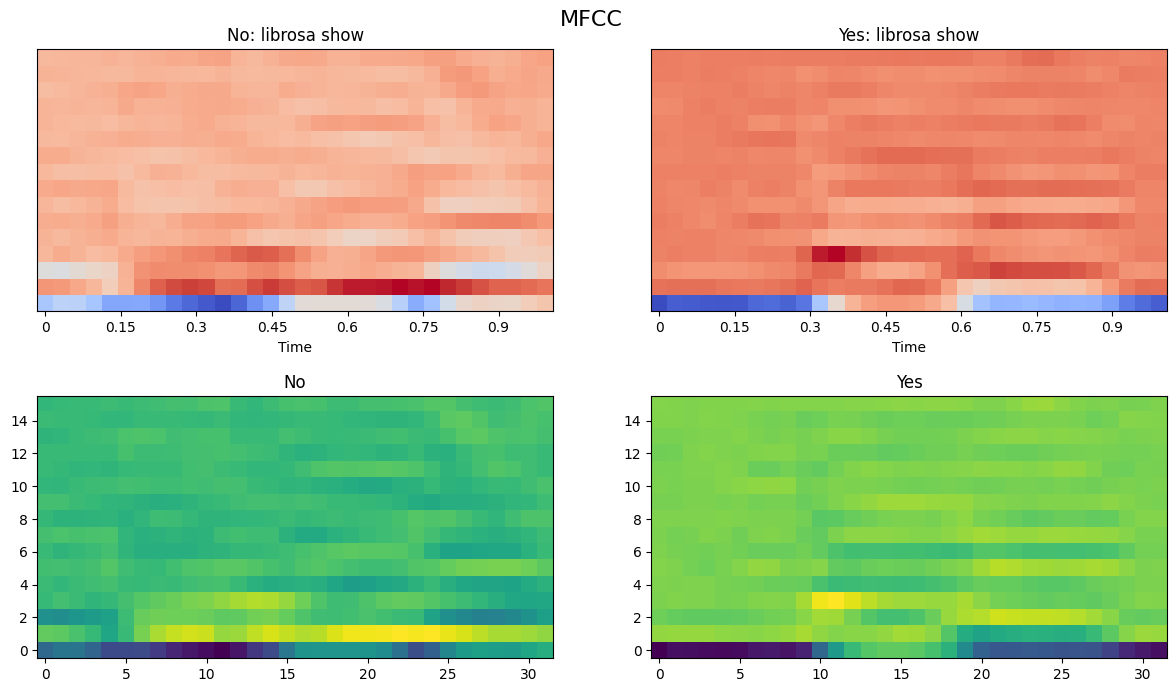

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(12, 7))
fig.suptitle('MFCC', fontsize=16)

plt.tight_layout(pad=1, w_pad=4, h_pad=4.0)

mfccs_no = librosa.feature.mfcc(y=wave_no[0].numpy(), sr=16_000, n_mfcc=16)
mfccs_yes = librosa.feature.mfcc(y=wave_yes[0].numpy(), sr=16_000, n_mfcc=16)

ax[0, 0].set_title('No: librosa show')
librosa.display.specshow(mfccs_no, x_axis='time', sr=16_000, ax=ax[0, 0])

ax[0, 1].set_title('Yes: librosa show')
librosa.display.specshow(mfccs_yes, x_axis='time', sr=16_000, ax=ax[0, 1])

ax[1, 0].set_title('No')
ax[1,0].imshow(mfccs_no, aspect='auto', origin='lower')# cmap='magma'

ax[1, 1].set_title('Yes')
ax[1,1].imshow(mfccs_yes, aspect='auto', origin='lower')

print(mfccs_yes.shape)

## Train_model

In [ ]:
def train(model, optimizer, criterion, train_dataloader, test_loader, n_epochs=10, device=None, plot=True):
    model = model.to(device)
    criterion = criterion.to(device)

    train_loss_epochs = []
    train_accuracy_epochs = []

    valid_loss_epochs = []
    valid_accuracy_epochs = []

    for epoch in range(n_epochs):
        # train
        train_loss_step = []
        train_accuracy_step = []
        for x_train, y_train in tqdm(train_dataloader, desc=f"Epoch {epoch+1} Train"):
            x_train = x_train.to(device)
            y_train = y_train.to(device)

            optimizer.zero_grad()
            y_pred_logits = model(x_train)
            loss = criterion(y_pred_logits, y_train)
            loss.backward()
            optimizer.step()

            y_pred_probs = torch.sigmoid(y_pred_logits)
            y_pred_classes = (y_pred_probs > 0.5).float()
            accuracy = (y_pred_classes == y_train).sum().item()/y_train.size(0)

            train_loss_step.append(loss.item())
            train_accuracy_step.append(accuracy)

        train_loss_epochs.append(
            sum(train_loss_step)/len(train_loss_step)
            )
        train_accuracy_epochs.append(
            sum(train_accuracy_step)/len(train_accuracy_step)
            )

        # valid
        model.eval()
        valid_loss_step = []
        valid_accuracy_step = []
        with torch.no_grad():
          for x_val, y_val in tqdm(test_loader, desc=f"Epoch {epoch+1} Val"):
                x_val = x_val.to(device)
                y_val = y_val.to(device)

                y_pred_logits = model(x_val)
                loss = criterion(y_pred_logits, y_val)

                valid_loss_step.append(loss.item())

                y_pred_probs = torch.sigmoid(y_pred_logits)
                y_pred_classes = (y_pred_probs > 0.5).float()
                val_acccuracy = (y_pred_classes == y_val).sum().item()/y_val.size(0)
                valid_accuracy_step.append(val_acccuracy)

        valid_loss_epochs.append(
            sum(valid_loss_step)/len(valid_loss_step)
            )
        valid_accuracy_epochs.append(
            sum(valid_accuracy_step)/len(valid_accuracy_step)
            )

        if plot:
            clear_output(True)
            print(f'Epoch: {epoch+1}/{n_epochs} | '
                  f'Train Loss: {train_loss_epochs[-1]:.4f} Acc: {train_accuracy_epochs[-1]:.4f} | '
                  f'Val Loss: {valid_loss_epochs[-1]:.4f} Acc: {valid_accuracy_epochs[-1]:.4f}'
                  )

            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(train_loss_epochs, label='Train')
            plt.plot(valid_loss_epochs, label='Valid')
            plt.xlabel('Epochs', fontsize=16)
            plt.ylabel('Loss', fontsize=16)
            plt.legend(loc=0, fontsize=16)
            plt.grid('on')
            plt.subplot(1, 2, 2)
            plt.plot(train_accuracy_epochs, label='Train accuracy')
            plt.plot(valid_accuracy_epochs, label='Valid accuracy')
            plt.xlabel('Epochs', fontsize=16)
            plt.ylabel('Accuracy', fontsize=16)
            plt.legend(loc=0, fontsize=16)
            plt.grid('on')
            plt.show()
    return train_loss_epochs, train_accuracy_epochs, valid_loss_epochs, valid_accuracy_epochs

In [ ]:
class Wave_Net(nn.Module): # Есть нейросеть с таким названием, и у нее другая архитектура). У нас это будет классический MLP)
    def __init__(self, input_size=16000, dropout_rate=0.1):
        super(Wave_Net, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = Wave_Net().to(device)
summary(model, (1, 16_000))
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)
criterion = nn.BCEWithLogitsLoss()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                [-1, 16000]               0
            Linear-2                   [-1, 64]       1,024,064
              ReLU-3                   [-1, 64]               0
           Dropout-4                   [-1, 64]               0
            Linear-5                   [-1, 32]           2,080
              ReLU-6                   [-1, 32]               0
           Dropout-7                   [-1, 32]               0
            Linear-8                    [-1, 1]              33
Total params: 1,026,177
Trainable params: 1,026,177
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.06
Forward/backward pass size (MB): 0.12
Params size (MB): 3.91
Estimated Total Size (MB): 4.10
----------------------------------------------------------------


Epoch: 10/10 | Train Loss: 0.5401 Acc: 0.8256 | Val Loss: 0.6961 Acc: 0.5435


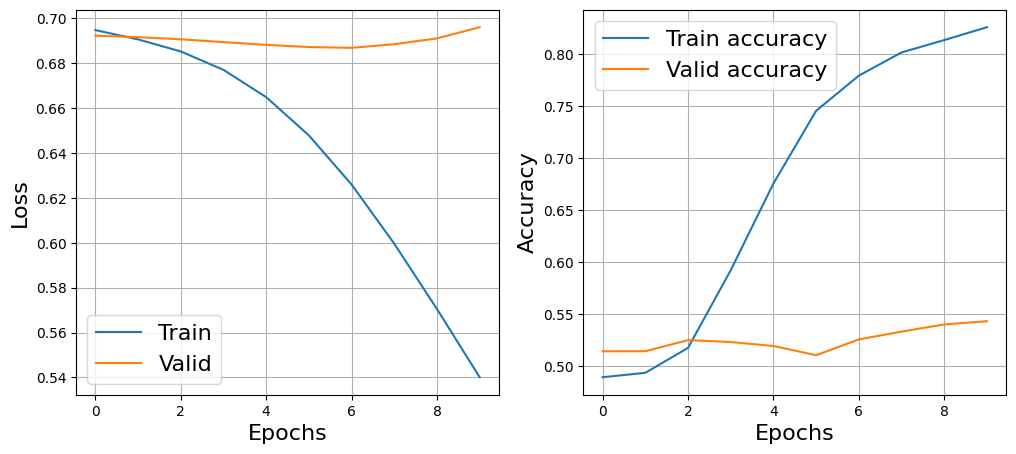

In [ ]:
train_loss_epochs, train_accuracy_epochs, valid_loss_epochs, valid_accuracy_epochs = train(
    model,
    optimizer,
    criterion,
    train_loader,
    test_loader,
    n_epochs=10,
    device=device
    )

Полносвязнаяя сеть не может учитывать контекст (соседние сэмплы  становятся просто независимыми признаками) + не инвариативна к сдвигу, что в звуке обычное дело. Сеть теряет информацию о порядке и временных зависимостях

**Аудио — это последовательность, где контекст важен.** Поэтому используют свертку.

Свертка скользит по временной оси, анализируя локальные паттерны (формы волн, частоты). Она понимает, что сэмплы, идущие друг за другом, связаны между собой.

In [ ]:
class WaveCNN(nn.Module):
    def __init__(self, num_classes=1):
        super(WaveCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=4, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(4),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv1d(in_channels=4, out_channels=8, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv1d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.fc = nn.Linear(16, num_classes)

    def forward(self, x):
        # x shape: (Batch, Channels, Time)
        if x.dim() == 2:
            x = x.unsqueeze(1)

        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)

        x = x.view(x.size(0), -1) # (Batch, 64)
        logits = self.fc(x)       # (Batch, 1)

        return logits.squeeze(1)

In [ ]:
model = WaveCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)
criterion = nn.BCEWithLogitsLoss()
summary(model, (1, sr))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1              [-1, 4, 8000]              32
       BatchNorm1d-2              [-1, 4, 8000]               8
              ReLU-3              [-1, 4, 8000]               0
         MaxPool1d-4              [-1, 4, 3999]               0
            Conv1d-5              [-1, 8, 2000]             168
       BatchNorm1d-6              [-1, 8, 2000]              16
              ReLU-7              [-1, 8, 2000]               0
         MaxPool1d-8               [-1, 8, 999]               0
            Conv1d-9              [-1, 16, 999]             400
      BatchNorm1d-10              [-1, 16, 999]              32
             ReLU-11              [-1, 16, 999]               0
AdaptiveAvgPool1d-12                [-1, 16, 1]               0
           Linear-13                    [-1, 1]              17
Total params: 673
Trainable params: 673

Epoch: 10/10 | Train Loss: 0.5543 Acc: 0.8367 | Val Loss: 0.5394 Acc: 0.8477


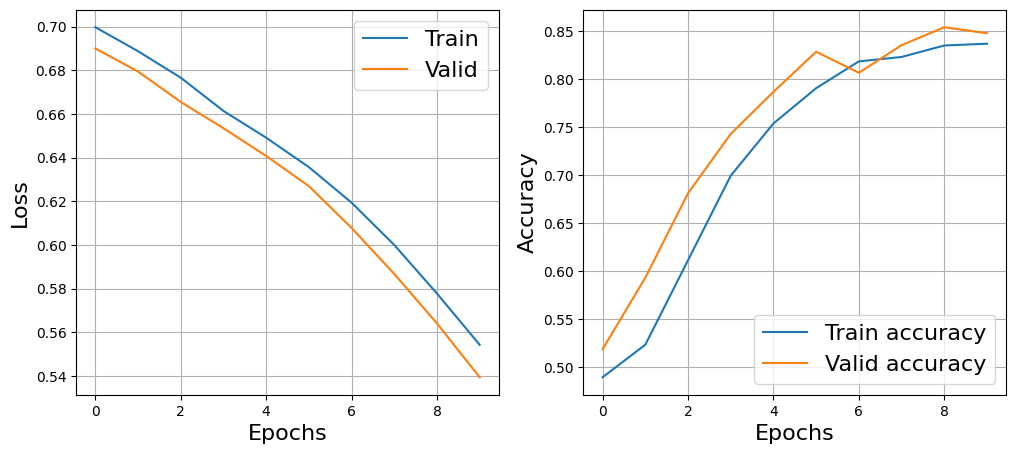

In [ ]:
# Запуск
train_loss_epochs, train_accuracy_epochs, valid_loss_epochs, valid_accuracy_epochs = train(
    model,
    optimizer,
    criterion,
    train_loader,
    test_loader,
    n_epochs=10,
    device=device
    )

**Тест голоса**

Обратите внимание, что диктофон в смартфоне отдает формат (в основном .m4a) — это сжатый формат.

Для прогона модели нам необходим формат .wav или .flac.

Получить его можно с помощью [ffmpeg](https://www.ffmpeg.org/) или [онлайн-конвертеров](https://convertio.co/ru/m4a-wav/).

Я пользуюсь ffmpeg:
```
ffmpeg -i input.m4a my_voice.wav
```

In [ ]:
waveform, rate = torchaudio.load('my_voice.wav') #

if sr != rate: # приводим частоту дискритизации к sr
   waveform = F.resample(waveform, orig_freq=rate, new_freq=sr)

# Обрезка или дополнение до 1 секунды
if waveform.shape[1] > length:
    waveform = waveform[:, :length]
elif waveform.shape[1] < length:
    padding = length - waveform.shape[1]
    waveform = torch.nn.functional.pad(waveform, (0, padding))

Audio(waveform, rate=sr)

In [ ]:
pred_logits = model(waveform[0][None][None].to(device))
pred_probs = torch.sigmoid(pred_logits)
pred_classes = (pred_probs > 0.5).float()
print(f'class: {pred_classes.item()}, probs: {pred_probs.item()}')

class: 1.0, probs: 0.7460216879844666


## HomeWork 15б.

* Поэкспериментировать с признаками (фичами)
* Поэкспериментировать с архитектурами модели
* Выучить свою модель
* Протестируйте модель на своем голосе)
